# Phase 1: Exploratory Data Analysis — MovieLens-1M
Goals: understand the data shape, sparsity, rating distribution, user activity, and item popularity.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import load_ratings, load_movies, load_users, split_per_user, build_interaction_matrix, compute_sparsity

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)

## 1. Load Data

In [2]:
ratings = load_ratings()
movies  = load_movies()
users   = load_users()

print(f"Ratings : {ratings.shape}  — {ratings.shape[0]:,} rows")
print(f"Movies  : {movies.shape}")
print(f"Users   : {users.shape}")
ratings.head()

Ratings : (1000209, 4)  — 1,000,209 rows
Movies  : (3883, 3)
Users   : (6040, 5)


,userId,movieId,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


## 2. Basic Stats

In [3]:
n_users  = ratings['userId'].nunique()
n_items  = ratings['movieId'].nunique()
n_ratings = len(ratings)

print(f"Unique users  : {n_users:,}")
print(f"Unique movies : {n_items:,}")
print(f"Total ratings : {n_ratings:,}")
print(f"Rating scale  : {ratings['rating'].min()} – {ratings['rating'].max()}")
print(f"Avg ratings per user  : {n_ratings / n_users:.1f}")
print(f"Avg ratings per movie : {n_ratings / n_items:.1f}")

Unique users  : 6,040
Unique movies : 3,706
Total ratings : 1,000,209
Rating scale  : 1 – 5
Avg ratings per user  : 165.6
Avg ratings per movie : 269.9


## 3. Sparsity

In [4]:
R = build_interaction_matrix(ratings, n_users=n_users, n_items=ratings['movieId'].max())
sparsity = compute_sparsity(R)

print(f"Matrix shape : {R.shape}")
print(f"Non-zero     : {R.nnz:,}")
print(f"Sparsity     : {sparsity * 100:.2f}%")

Matrix shape : (6040, 3952)
Non-zero     : 1,000,209
Sparsity     : 95.81%


## 4. Rating Distribution

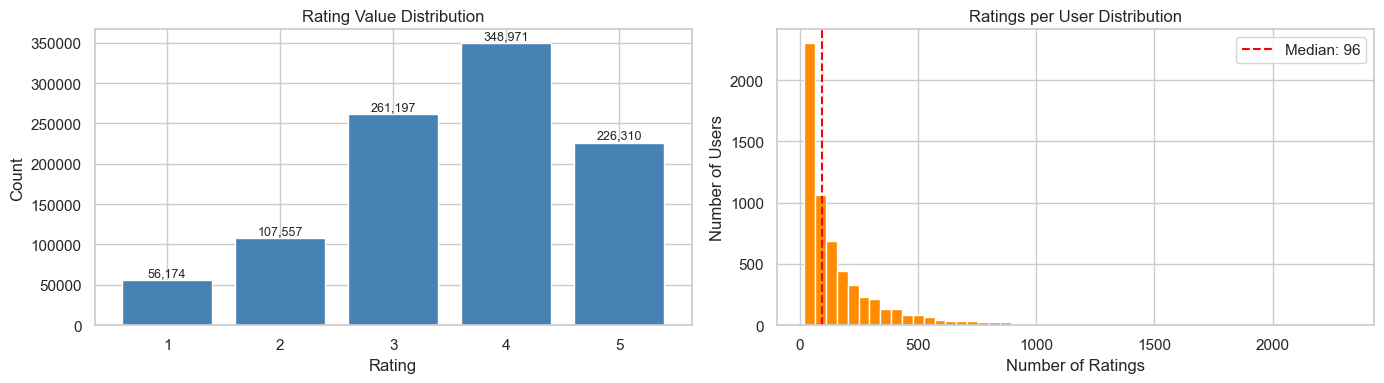

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Rating value counts
rating_counts = ratings['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Rating Value Distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
for x, y in zip(rating_counts.index, rating_counts.values):
    axes[0].text(x, y + 5000, f'{y:,}', ha='center', fontsize=9)

# Ratings per user (log scale)
ratings_per_user = ratings.groupby('userId').size()
axes[1].hist(ratings_per_user, bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Ratings per User Distribution')
axes[1].set_xlabel('Number of Ratings')
axes[1].set_ylabel('Number of Users')
axes[1].axvline(ratings_per_user.median(), color='red', linestyle='--', label=f'Median: {ratings_per_user.median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/rating_distribution.png', dpi=120)
plt.show()

## 5. Item Popularity — Long-Tail Effect

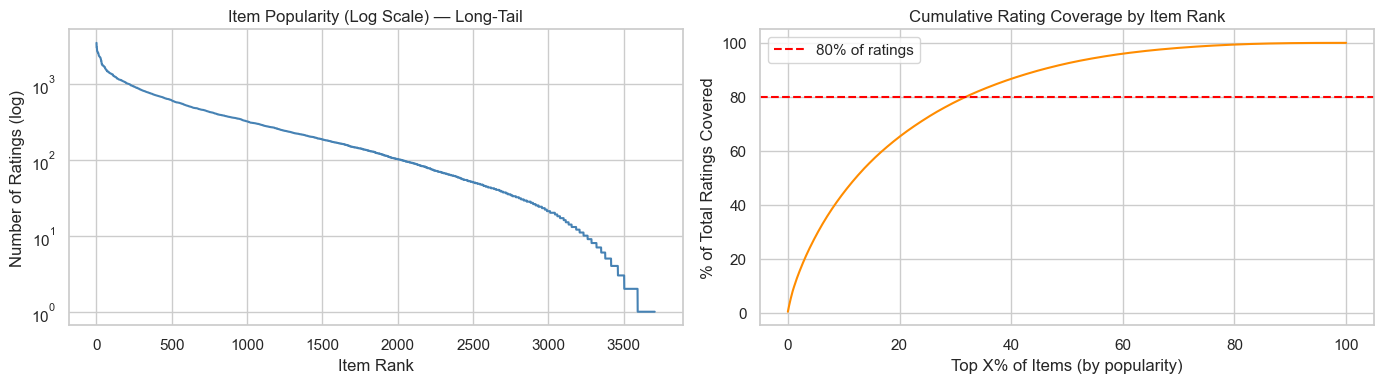

Top 1181 items (31.9% of catalog) account for 80% of all ratings


In [6]:
ratings_per_movie = ratings.groupby('movieId').size().sort_values(ascending=False).reset_index()
ratings_per_movie.columns = ['movieId', 'n_ratings']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Raw count (log scale shows long tail clearly)
axes[0].plot(range(len(ratings_per_movie)), ratings_per_movie['n_ratings'], color='steelblue')
axes[0].set_yscale('log')
axes[0].set_title('Item Popularity (Log Scale) — Long-Tail')
axes[0].set_xlabel('Item Rank')
axes[0].set_ylabel('Number of Ratings (log)')

# What % of ratings do top-N% items capture?
total = ratings_per_movie['n_ratings'].sum()
ratings_per_movie['cumulative_pct'] = ratings_per_movie['n_ratings'].cumsum() / total * 100
axes[1].plot(np.linspace(0, 100, len(ratings_per_movie)), ratings_per_movie['cumulative_pct'], color='darkorange')
axes[1].axhline(80, color='red', linestyle='--', label='80% of ratings')
axes[1].set_title('Cumulative Rating Coverage by Item Rank')
axes[1].set_xlabel('Top X% of Items (by popularity)')
axes[1].set_ylabel('% of Total Ratings Covered')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/item_popularity.png', dpi=120)
plt.show()

# How many items cover 80% of ratings?
cutoff = ratings_per_movie[ratings_per_movie['cumulative_pct'] <= 80].shape[0]
print(f"Top {cutoff} items ({cutoff/n_items*100:.1f}% of catalog) account for 80% of all ratings")

## 6. Top-10 Most & Least Rated Movies

In [7]:
movie_stats = ratings.groupby('movieId').agg(
    n_ratings=('rating', 'count'),
    avg_rating=('rating', 'mean')
).reset_index().merge(movies[['movieId', 'title']], on='movieId')

print("Top 10 Most Rated:")
display(movie_stats.sort_values('n_ratings', ascending=False).head(10)[['title', 'n_ratings', 'avg_rating']])

print("\nTop 10 Least Rated (long-tail):")
display(movie_stats.sort_values('n_ratings').head(10)[['title', 'n_ratings', 'avg_rating']])

Top 10 Most Rated:


,title,n_ratings,avg_rating
2651,American Beauty (1999),3428,4.317386
253,Star Wars: Episode IV - A New Hope (1977),2991,4.453694
1106,Star Wars: Episode V - The Empire Strikes Back...,2990,4.292977
1120,Star Wars: Episode VI - Return of the Jedi (1983),2883,4.022893
466,Jurassic Park (1993),2672,3.763847
1848,Saving Private Ryan (1998),2653,4.337354
575,Terminator 2: Judgment Day (1991),2649,4.058513
2374,"Matrix, The (1999)",2590,4.315830
1178,Back to the Future (1985),2583,3.990321
579,"Silence of the Lambs, The (1991)",2578,4.351823



Top 10 Least Rated (long-tail):


,title,n_ratings,avg_rating
774,Diebinnen (1995),1,1.0
1672,Love Walked In (1998),1,2.0
3644,Back Stage (2000),1,3.0
2850,Ten Benny (1997),1,4.0
1358,Rhyme & Reason (1997),1,4.0
1496,"Lay of the Land, The (1997)",1,2.0
3414,Lured (1947),1,5.0
1858,Cheetah (1989),1,1.0
1576,Full Speed (1996),1,3.0
3225,Blood and Sand (Sangre y Arena) (1989),1,3.0


## 7. User Activity Distribution

In [8]:
user_activity = ratings.groupby('userId').size().describe()
print("Ratings per user stats:")
print(user_activity)

# Users with fewer than 20 ratings — cold-start territory
cold_users = (ratings.groupby('userId').size() < 20).sum()
print(f"\nUsers with < 20 ratings (cold-start): {cold_users:,} ({cold_users/n_users*100:.1f}%)")

Ratings per user stats:
count    6040.000000
mean      165.597517
std       192.747029
min        20.000000
25%        44.000000
50%        96.000000
75%       208.000000
max      2314.000000
dtype: float64

Users with < 20 ratings (cold-start): 0 (0.0%)


## 8. Genre Distribution

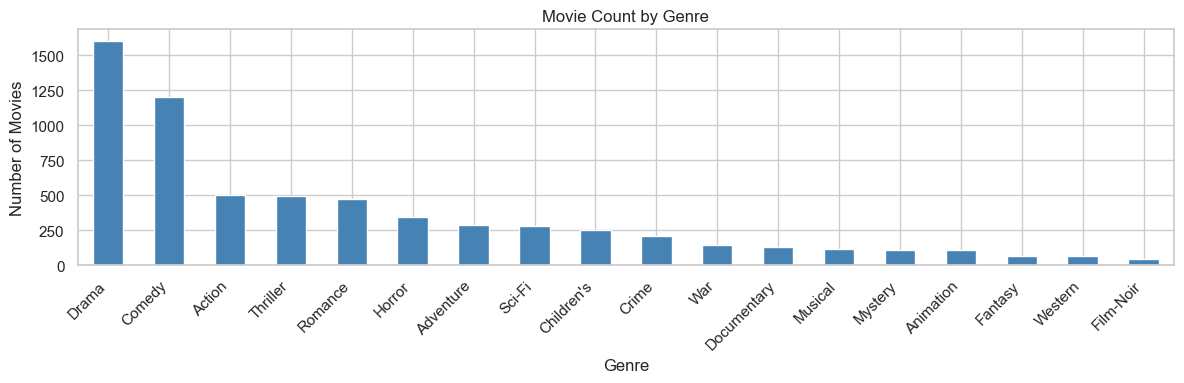

In [9]:
genre_counts = movies['genres'].str.split('|').explode().value_counts()

plt.figure(figsize=(12, 4))
genre_counts.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Movie Count by Genre')
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/genre_distribution.png', dpi=120)
plt.show()

## 9. Train / Val / Test Split

In [10]:
train, val, test = split_per_user(ratings, test_ratio=0.1, val_ratio=0.1)

print(f"Train : {len(train):>8,} ratings  ({len(train)/len(ratings)*100:.1f}%)")
print(f"Val   : {len(val):>8,} ratings  ({len(val)/len(ratings)*100:.1f}%)")
print(f"Test  : {len(test):>8,} ratings  ({len(test)/len(ratings)*100:.1f}%)")

# Verify all users appear in train
assert set(train['userId'].unique()) == set(ratings['userId'].unique()), "Some users missing from train!"
print("\nAll users present in train set.")

# Save splits
train.to_csv('../data/train.csv', index=False)
val.to_csv('../data/val.csv', index=False)
test.to_csv('../data/test.csv', index=False)
print("Splits saved to data/")

Train :  805,443 ratings  (80.5%)
Val   :   97,383 ratings  (9.7%)
Test  :   97,383 ratings  (9.7%)

All users present in train set.
Splits saved to data/


## 10. Summary

| Stat | Value |
|------|-------|
| Users | 6,040 |
| Movies | ~3,706 unique rated |
| Ratings | 1,000,209 |
| Sparsity | ~95%+ |
| Avg ratings/user | ~165 |
| Avg ratings/movie | ~270 |

**Key observations:**
- Strong long-tail: a small fraction of movies get the majority of ratings
- Rating distribution skews positive (users tend to rate movies they liked)
- Cold-start users (< 20 ratings) need special handling — covered in Phase 10